In [1]:
# loading modules

# %load_ext watermark # this is so that in the end we can check which module versions we used
%load_ext autoreload

import warnings 
warnings.filterwarnings("ignore")

import datetime
import glob
import os
import warnings
import dask
import distributed
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgcm
from matplotlib import ticker, cm
from cartopy import crs as ccrs, feature as cfeature
import cartopy
from pyproj import CRS, Transformer
import xesmf as xe
from skimage import measure


In [4]:
cism_grid_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.LatLon.nc"
cism_init_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc"

lgm_ocn_temp_path = "/glade/u/home/ifairuz/processed_paleo_data/LGM/icesm_lgm21ka_ocn_TEMP_monthly_avg_antarctica.nc"
lig_ocn_temp_path = "/glade/u/home/ifairuz/processed_paleo_data/LIG/icesm_lig127ka_ocn_TEMP_monthly_avg_antarctica.nc"


In [5]:
cism_grid_ds = xr.open_dataset(cism_grid_path)
cism_init_ds = xr.open_dataset(cism_init_path)
lgm_ocn_temp_ds = xr.open_dataset(lgm_ocn_temp_path, chunks={"time": 12})
lig_ocn_temp_ds = xr.open_dataset(lig_ocn_temp_path, chunks={"time": 12})

In [10]:
lgm_salt_ds = xr.open_dataset("/glade/u/home/ifairuz/processed_paleo_data/LGM/icesm_lgm21ka_ocn_SALT_monthly_avg_antarctica.nc", chunks={"time": 12})
lig_salt_ds = xr.open_dataset("/glade/u/home/ifairuz/processed_paleo_data/LIG/icesm_lig127ka_ocn_SALT_monthly_avg_antarctica.nc", chunks={"time": 12})

In [11]:
def clean_pop_coords(ds):
    drop_vars = [v for v in ['lat_aux_grid', 'moc_z', 'z_t_150m', 'z_w', 'z_w_bot', 'z_w_top'] if v in ds]
    ds = ds.drop_vars(drop_vars)
    ds = ds.assign_coords(
        lon=(("nlat", "nlon"), ds["lon"].values, {"name": "longitude", "units": "degrees_east"}),
        lat=(("nlat", "nlon"), ds["lat"].values, {"name": "latitude", "units": "degrees_north"})
    )
    return ds

lgm_ocn_temp_ds = clean_pop_coords(lgm_ocn_temp_ds)
lig_ocn_temp_ds = clean_pop_coords(lig_ocn_temp_ds)
lgm_salt_ds = clean_pop_coords(lgm_salt_ds)
lig_salt_ds = clean_pop_coords(lig_salt_ds)

In [14]:
ref = xr.open_dataset("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc", decode_cf=False)

In [15]:
print("POP z_t:", lgm_ocn_temp_ds["z_t"].values)
print("units:", lgm_ocn_temp_ds["z_t"].attrs.get("units", "?"))
print("TEMP attrs:", lgm_ocn_temp_ds["TEMP"].attrs)
print("SALT attrs:", lgm_salt_ds["SALT"].attrs)
print("\nreference zocn:", ref["zocn"].values)

POP z_t: [5.0000000e+02 1.5000000e+03 2.5000000e+03 3.5000000e+03 4.5000000e+03
 5.5000000e+03 6.5000000e+03 7.5000000e+03 8.5000000e+03 9.5000000e+03
 1.0500000e+04 1.1500000e+04 1.2500000e+04 1.3500000e+04 1.4500000e+04
 1.5500000e+04 1.6509840e+04 1.7547904e+04 1.8629127e+04 1.9766027e+04
 2.0971139e+04 2.2257828e+04 2.3640883e+04 2.5137016e+04 2.6765420e+04
 2.8548365e+04 3.0511922e+04 3.2686799e+04 3.5109348e+04 3.7822762e+04
 4.0878465e+04 4.4337770e+04 4.8273672e+04 5.2772801e+04 5.7937289e+04
 6.3886262e+04 7.0756328e+04 7.8700250e+04 8.7882523e+04 9.8470586e+04
 1.1062042e+05 1.2445669e+05 1.4004972e+05 1.5739464e+05 1.7640033e+05
 1.9689442e+05 2.1864566e+05 2.4139716e+05 2.6490012e+05 2.8893847e+05
 3.1334047e+05 3.3797934e+05 3.6276703e+05 3.8764519e+05 4.1257681e+05
 4.3753925e+05 4.6251903e+05 4.8750834e+05 5.1250281e+05 5.3750000e+05]
units: centimeters
TEMP attrs: {'long_name': 'Potential Temperature', 'units': 'degC', 'grid_loc': '3111', 'cell_methods': 'time: mean'}
S

In [16]:
# Convert POP z_t from cm to meters (positive downward)
pop_z_meters = lgm_ocn_temp_ds["z_t"].values / 100.0
zocn_positive = np.abs(ref["zocn"].values)  # make positive for interpolation

# Build CISM target grid
grid_thick = xr.Dataset(
    {
        "lat": (("y1", "x1"), cism_grid_ds["Lat1"].data),
        "lon": (("y1", "x1"), cism_grid_ds["Lon1"].data)
    }
)

# Build regridders for TEMP and SALT
pop_lgm_regridder = xe.Regridder(lgm_ocn_temp_ds[["TEMP"]], grid_thick,
                                  method="bilinear", periodic=True)
pop_lig_regridder = xe.Regridder(lig_ocn_temp_ds[["TEMP"]], grid_thick,
                                  method="bilinear", periodic=True)

# Regrid TEMP and SALT horizontally
lgm_temp_regridded = pop_lgm_regridder(lgm_ocn_temp_ds[["TEMP"]])
lig_temp_regridded = pop_lig_regridder(lig_ocn_temp_ds[["TEMP"]])
lgm_salt_regridded = pop_lgm_regridder(lgm_salt_ds[["SALT"]])
lig_salt_regridded = pop_lig_regridder(lig_salt_ds[["SALT"]])

# Assign z_t in meters as a coordinate
for ds in [lgm_temp_regridded, lig_temp_regridded, lgm_salt_regridded, lig_salt_regridded]:
    ds["z_t"] = pop_z_meters

# Interpolate vertically onto zocn levels
lgm_temp_interp = lgm_temp_regridded.interp(z_t=zocn_positive)
lig_temp_interp = lig_temp_regridded.interp(z_t=zocn_positive)
lgm_salt_interp = lgm_salt_regridded.interp(z_t=zocn_positive)
lig_salt_interp = lig_salt_regridded.interp(z_t=zocn_positive)

In [17]:
# Freezing point formula (ISMIP6 protocol)
# T_freeze = 0.0939 - 0.057 * S + 7.64e-4 * z  (z positive downward in meters)
def compute_thermal_forcing(temp, salt, z_levels):
    """temp and salt already interpolated onto zocn levels"""
    T_freeze = 0.0939 - 0.057 * salt + 7.64e-4 * z_levels
    TF = temp - T_freeze
    return TF

# Compute TF — need zocn as a DataArray with correct dims for broadcasting
zocn_da = xr.DataArray(zocn_positive, dims=["z_t"], coords={"z_t": zocn_positive})

lgm_TF = compute_thermal_forcing(lgm_temp_interp["TEMP"], lgm_salt_interp["SALT"], zocn_da)
lig_TF = compute_thermal_forcing(lig_temp_interp["TEMP"], lig_salt_interp["SALT"], zocn_da)

In [18]:
print(lgm_temp_regridded)
print(lgm_salt_regridded)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, z_t: 60, y1: 761, x1: 761)
Coordinates:
  * z_t      (z_t) float32 240B 5.0 15.0 25.0 ... 4.875e+03 5.125e+03 5.375e+03
  * time     (time) float64 96B 0.0 0.08333 0.1667 0.25 ... 0.75 0.8333 0.9167
Dimensions without coordinates: y1, x1
Data variables:
    TEMP     (time, z_t, y1, x1) float32 2GB dask.array<chunksize=(12, 60, 761, 761), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear
<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, z_t: 60, y1: 761, x1: 761)
Coordinates:
  * z_t      (z_t) float32 240B 5.0 15.0 25.0 ... 4.875e+03 5.125e+03 5.375e+03
  * time     (time) float64 96B 0.0 0.08333 0.1667 0.25 ... 0.75 0.8333 0.9167
Dimensions without coordinates: y1, x1
Data variables:
    SALT     (time, z_t, y1, x1) float32 2GB dask.array<chunksize=(12, 60, 761, 761), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear


In [19]:
# zocn levels as positive meters for interpolation
zocn_positive = np.abs(ref["zocn"].values)
zocn_da = xr.DataArray(zocn_positive, dims=["z_t"], coords={"z_t": zocn_positive})

# Vertical interpolation onto zocn levels
lgm_temp_interp = lgm_temp_regridded.interp(z_t=zocn_positive)
lig_temp_interp = lig_temp_regridded.interp(z_t=zocn_positive)
lgm_salt_interp = lgm_salt_regridded.interp(z_t=zocn_positive)
lig_salt_interp = lig_salt_regridded.interp(z_t=zocn_positive)

# Compute thermal forcing (ISMIP6 protocol)
def compute_thermal_forcing(temp, salt, z_da):
    T_freeze = 0.0939 - 0.057 * salt + 7.64e-4 * z_da
    return temp - T_freeze

lgm_TF = compute_thermal_forcing(lgm_temp_interp["TEMP"], lgm_salt_interp["SALT"], zocn_da)
lig_TF = compute_thermal_forcing(lig_temp_interp["TEMP"], lig_salt_interp["SALT"], zocn_da)

# Quick sanity check before saving
print(lgm_TF)
print("LGM TF min:", float(lgm_TF.min()))
print("LGM TF max:", float(lgm_TF.max()))
print("LIG TF min:", float(lig_TF.min()))
print("LIG TF max:", float(lig_TF.max()))

<xarray.DataArray (time: 12, z_t: 30, y1: 761, x1: 761)> Size: 834MB
dask.array<sub, shape=(12, 30, 761, 761), dtype=float32, chunksize=(12, 30, 761, 761), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float64 96B 0.0 0.08333 0.1667 0.25 ... 0.75 0.8333 0.9167
  * z_t      (z_t) float32 120B 30.0 90.0 150.0 ... 1.65e+03 1.71e+03 1.77e+03
Dimensions without coordinates: y1, x1
LGM TF min: -1.2755359411239624
LGM TF max: 6.3213791847229
LIG TF min: -1.4503989219665527
LIG TF max: 11.659565925598145


In [21]:
lon2d = cism_grid_ds["Lon1"].values
lat2d = cism_grid_ds["Lat1"].values

# Package into datasets and assign coordinates
lgm_TF_ds = lgm_TF.to_dataset(name="thermal_forcing")\
    .rename({"z_t": "zocn"})\
    .assign_coords(
        lat=(("y1", "x1"), lat2d),
        lon=(("y1", "x1"), lon2d),
        zocn=("zocn", -zocn_positive)
    )

lig_TF_ds = lig_TF.to_dataset(name="thermal_forcing")\
    .rename({"z_t": "zocn"})\
    .assign_coords(
        lat=(("y1", "x1"), lat2d),
        lon=(("y1", "x1"), lon2d),
        zocn=("zocn", -zocn_positive)
    )

# Add attributes to match reference
for ds in [lgm_TF_ds, lig_TF_ds]:
    ds["thermal_forcing"].attrs["long_name"] = "thermal forcing, the difference between the temperature and the local freezing point"
    ds["thermal_forcing"].attrs["units"] = "degree celsius"
    ds["thermal_forcing"].attrs["interpolation"] = "bilinear"

# Set fill value for invalid cells to match reference (-99999)
lgm_TF_ds["thermal_forcing"] = lgm_TF_ds["thermal_forcing"].fillna(-99999)
lig_TF_ds["thermal_forcing"] = lig_TF_ds["thermal_forcing"].fillna(-99999)

# Save
lgm_TF_ds.to_netcdf("lgm21ka_ocn_thermal_forcing_on_cism8km.nc")
lig_TF_ds.to_netcdf("lig127ka_ocn_thermal_forcing_on_cism8km.nc")

print(lgm_TF_ds)
print(lig_TF_ds)

<xarray.Dataset> Size: 839MB
Dimensions:          (time: 12, zocn: 30, y1: 761, x1: 761)
Coordinates:
  * time             (time) float64 96B 0.0 0.08333 0.1667 ... 0.8333 0.9167
    lat              (y1, x1) float32 2MB -51.85 -51.9 -51.94 ... -51.9 -51.85
    lon              (y1, x1) float32 2MB 225.0 224.9 224.8 ... 44.85 44.92 45.0
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Dimensions without coordinates: y1, x1
Data variables:
    thermal_forcing  (time, zocn, y1, x1) float32 834MB dask.array<chunksize=(12, 30, 761, 761), meta=np.ndarray>
<xarray.Dataset> Size: 839MB
Dimensions:          (time: 12, zocn: 30, y1: 761, x1: 761)
Coordinates:
  * time             (time) float64 96B 0.0 0.08333 0.1667 ... 0.8333 0.9167
    lat              (y1, x1) float32 2MB -51.85 -51.9 -51.94 ... -51.9 -51.85
    lon              (y1, x1) float32 2MB 225.0 224.9 224.8 ... 44.85 44.92 45.0
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03

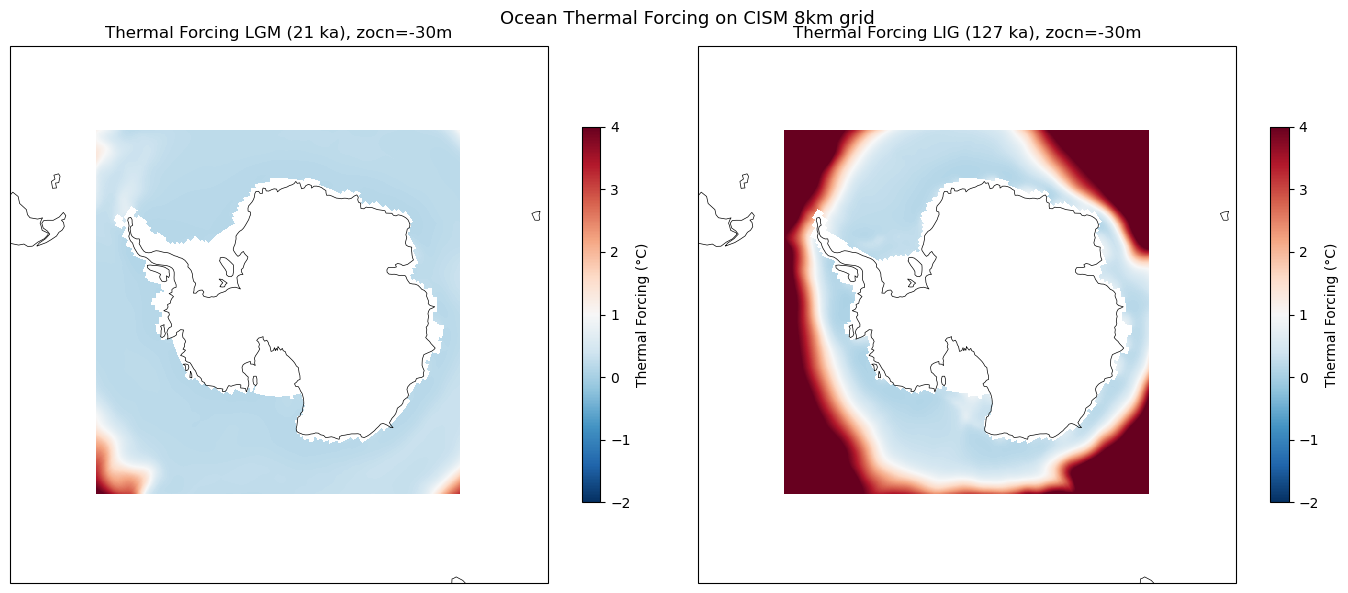

In [22]:
# Validation plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, ds, title in zip(axes,
                          [lgm_TF_ds, lig_TF_ds],
                          ["LGM (21 ka)", "LIG (127 ka)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    field = ds["thermal_forcing"].isel(time=0, zocn=0)
    field = field.where(field != -99999)

    p = ax.pcolormesh(
        lon2d, lat2d, field.values,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r", vmin=-2, vmax=4
    )
    plt.colorbar(p, ax=ax, label="Thermal Forcing (°C)", shrink=0.7)
    ax.set_title(f"Thermal Forcing {title}, zocn=-30m")

plt.suptitle("Ocean Thermal Forcing on CISM 8km grid", fontsize=13)
plt.tight_layout()
plt.savefig("LGM_LIG_thermal_forcing_cism8km.png", dpi=150)
plt.show()